# Business Questions (Superstore dataset)

### 14. Sales by Category and Region
### 15. Profit by Category and Region
### 16. Sales and Profit by Region
### 17. Monthly Sales by Category

18. What are the top 10 products by sales?
19. Which sub-categories generate losses?
20. Which regions generate the most profit?
21. Does discount appear to affect profit?
22. Which category has the highest sales?
23. How have sales changed over time?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/Superstore (1).csv')
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1.0,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2.0,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3.0,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4.0,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5.0,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 14. Sales by Category and Region

In [ ]:
df.pivot_table(values='Sales', index='Category', columns='Region', aggfunc='sum')

Region,Central,East,South,West
Category,,,,
Furniture,160317.4622,206461.388,116531.480,245348.2455
Office Supplies,163590.2430,199940.811,124424.771,217466.5090
Technology,168739.2080,263116.527,148195.208,247404.9300


## 15. Profit by Category and Region

In [ ]:
df.pivot_table(values='Profit', index='Category', columns='Region', aggfunc='sum')

Region,Central,East,South,West
Category,,,,
Furniture,-3281.0099,2958.2035,6662.2732,10582.2174
Office Supplies,7902.6109,39435.7747,19774.9800,51843.0205
Technology,33244.4609,47118.1022,19806.0084,42931.9690


## 16. Sales and Profit by Region

In [ ]:
df.groupby('Region')[['Sales', 'Profit']].sum()

,Sales,Profit
Region,,
Central,492646.9132,37866.0619
East,669518.7260,89512.0804
South,389151.4590,46243.2616
West,710219.6845,105357.2069


## 17. Monthly Sales by Category

In [ ]:
df['Month'] = df['Order Date'].dt.strftime('%Y-%m')
df.pivot_table(values='Sales', index='Month', columns='Category', aggfunc='sum')

Category,Furniture,Office Supplies,Technology
Month,,,
2015-01,6217.2770,4845.140,3143.290
2015-02,1839.6580,1071.724,1608.510
2015-03,14243.3680,8602.455,32359.974
2015-04,7944.8370,10988.874,8973.144
2015-05,6912.7870,7131.640,9599.876
2015-06,13144.5816,12742.389,8435.965
2015-07,10821.0510,15121.208,7839.284
2015-08,7125.2105,11055.276,8937.050
2015-09,23816.4808,27423.298,30383.748


## 18. What are the top 10 products by sales?

In [ ]:
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

## 19. Which sub-categories generate losses?

In [ ]:
profit = df.groupby('Sub-Category')['Profit'].sum()
profit[profit < 0]

Sub-Category
Bookcases    -3364.6896
Supplies     -1258.9387
Tables      -18223.9251
Name: Profit, dtype: float64

## 20. Which regions generate the most profit?

In [ ]:
df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

Region
West       105357.2069
East        89512.0804
South       46243.2616
Central     37866.0619
Name: Profit, dtype: float64

## 21. Does discount appear to affect profit?

<Axes: xlabel='Discount'>

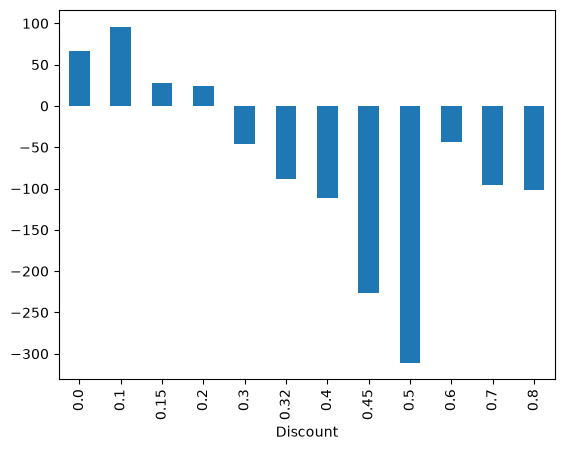

In [ ]:
df.groupby('Discount')['Profit'].mean().plot(kind='bar')

## 22. Which category has the highest sales?

In [ ]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

## 23. How have sales changed over time?

<Axes: xlabel='Order Date'>

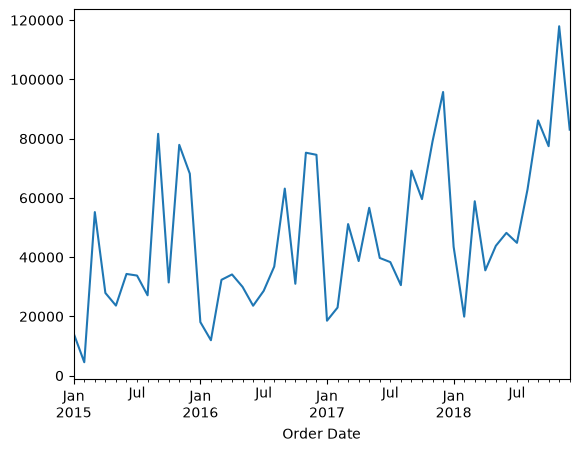

In [ ]:
df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().plot()